In [1]:
import numpy as np 
import xarray as xr
from matplotlib import pylab as plt
import matplotlib.colors as mcolors
imaus = ['IMAU_UFEMISM1','IMAU_UFEMISM2','IMAU_UFEMISM3','IMAU_UFEMISM4']
resolutions = ['32','32','16','16']
exps = ['expAE02','expAE03','expAE04','expAE05','ctrlAE']
IMAU =imaus[0]
exp = exps[0]
res = resolutions[0]

In [32]:
# for j,IMAU in enumerate(imaus):
#     res = resolutions[j]
#     for exp in exps:
        
# k=0
# l=9
pth = f'/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/CheckingIMAU/{IMAU}/{exp}_{res}/'
rho_ice = 910 
rho_ocean = 1028
dic={}
dic['floating_ice_mask']=f'sftflf_AIS_{IMAU}_{exp}.nc'
dic['ice_mask']=f'sftgif_AIS_{IMAU}_{exp}.nc'
dic['grounded_ice_mask']=f'sftgrf_AIS_{IMAU}_{exp}.nc'
dic['bmb']= f'libmassbffl_AIS_{IMAU}_{exp}.nc'

dic['thk']=f'lithk_AIS_{IMAU}_{exp}.nc'
dic['base']=f'base_AIS_{IMAU}_{exp}.nc'
dic['hs']=f'orog_AIS_{IMAU}_{exp}.nc'
dic['bed']=f'topg_AIS_{IMAU}_{exp}.nc'

### check consistency surface-thickness-base

In [3]:
#create thick calc 
d_icemask= xr.open_dataset(pth +dic['ice_mask'])
d_thk = xr.open_dataset(pth +dic['thk'])
d_hs = xr.open_dataset(pth +dic['hs'])
d_base = xr.open_dataset(pth + dic['base'])
d_bed = xr.open_dataset(pth + dic['bed'])
d_maskfloat  =xr.open_dataset(pth+ dic['floating_ice_mask'])
d_maskground  =xr.open_dataset(pth+ dic['grounded_ice_mask'])

In [4]:
#make copy of original false netcdf data for safety
d_maskfloat.to_netcdf(pth + 'orig_'+dic['floating_ice_mask'])

In [5]:
diff_h = d_hs['orog'].values -d_base['base'].values
diff = diff_h -  d_thk['lithk'].values

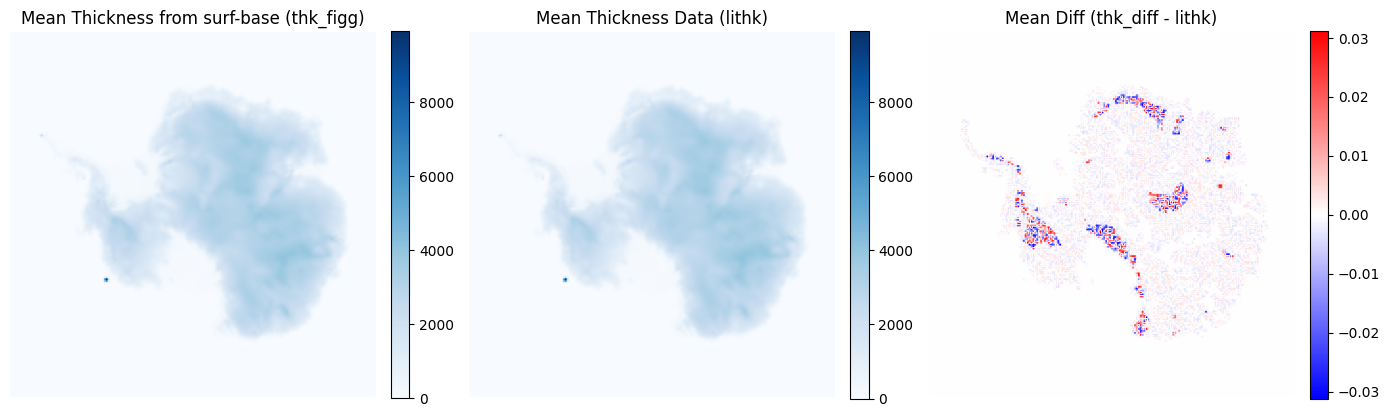

In [6]:
# Set up the figure and axes
f, ax = plt.subplots(1, 3, figsize=(14, 8))

# Plot the first panel
i = 0
im1 = ax[i].imshow(diff_h.mean(axis=0), origin='lower', cmap='Blues')
ax[i].set_title('Mean Thickness from surf-base (thk_figg)')
ax[i].axis('off')  # Turn off the axis

# Plot the second panel
i = 1
im2 = ax[i].imshow(d_thk['lithk'].mean(axis=0), origin='lower', cmap='Blues')
ax[i].set_title('Mean Thickness Data (lithk)')
ax[i].axis('off')  # Turn off the axis

# Plot the third panel with red-white-blue color map
i = 2
cmap_rwb = mcolors.LinearSegmentedColormap.from_list("RWB", ["blue", "white", "red"])
im3 = ax[i].imshow(diff.mean(axis=0), origin='lower', cmap=cmap_rwb, vmin=-np.max(diff.mean(axis=0)), vmax=np.max(diff.mean(axis=0)))
ax[i].set_title('Mean Diff (thk_diff - lithk)')
ax[i].axis('off')  # Turn off the axis

# Show color bars if needed
f.colorbar(im1, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
f.colorbar(im2, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
f.colorbar(im3, ax=ax[2], orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
f.savefig('figs/IMAU_interp_error.png')

assuming this are rounding errors....

In [8]:
# calc floating base from thk
base_float = d_thk['lithk'].values *-1*rho_ice/rho_ocean
m_float = base_float.copy() *0
m_float[base_float>d_bed['topg'].values] =1
m_float[d_icemask['sftgif'].values !=1]=0

In [9]:
#store new data
d_maskfloat_new = d_maskfloat.copy()
d_maskfloat_new['sftflf'].values = m_float
d_maskfloat_new.to_netcdf(pth +'new_'+dic['floating_ice_mask'])

In [10]:
#calc flaoting mask fromm base values outout
m_float2 = d_thk['lithk'].values*0
m_float2[d_base['base'].values >d_bed['topg'].values] =1
m_float2[d_icemask['sftgif'].values !=1]=0

In [11]:
d_maskfloat

<xarray.Dataset>
Dimensions:  (x: 191, y: 191, time: 286)
Coordinates:
  * x        (x) float32 9.969e+36 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * y        (y) float32 9.969e+36 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * time     (time) object 2015-01-01 00:00:00 ... 2300-01-01 00:00:00
Data variables:
    sftflf   (time, y, x) float32 ...

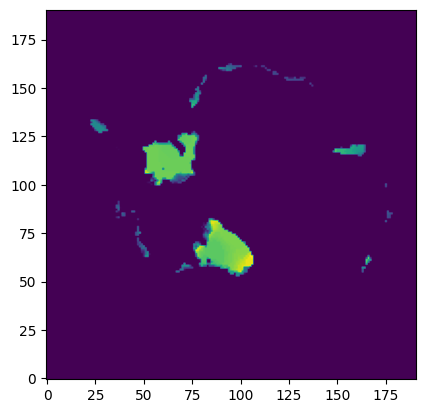

In [12]:
plt.imshow(m_float.mean(axis =0),origin = 'lower')

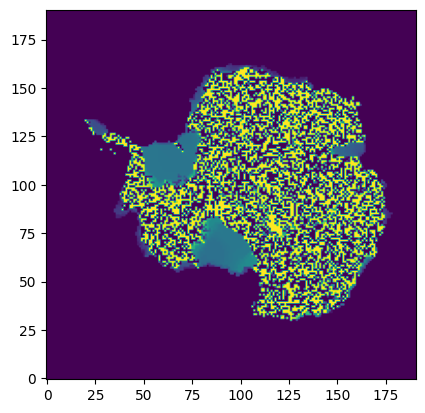

In [13]:
plt.imshow(m_float2.mean(axis =0),origin = 'lower')

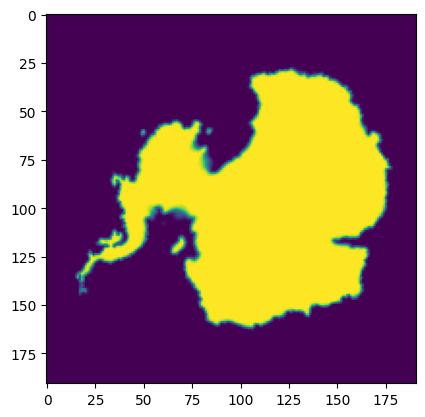

In [14]:
plt.imshow(d_maskground['sftgrf'].values.mean(axis =0))

Text(0.5, 1.0, 'ice mask mean')

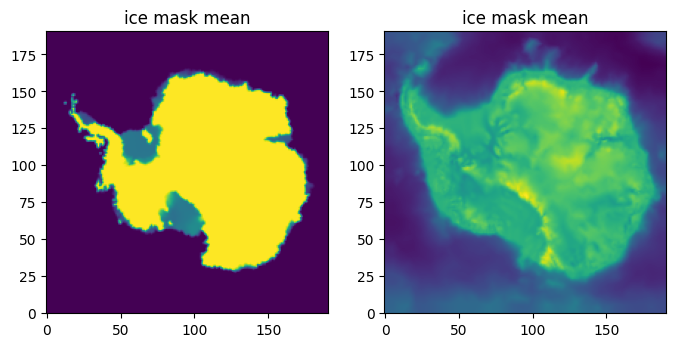

In [15]:
f,ax = plt.subplots(1,2,figsize = (8,8))
i = 0
ax[i].imshow(d_icemask['sftgif'].values.mean(axis = 0),origin = 'lower')
ax[i].set_title('ice mask mean')
i = 1
ax[i].imshow(d_bed['topg'].values.mean(axis = 0),origin = 'lower',)
ax[i].set_title('ice mask mean')


### Recalc Helenes 1_D data


In [88]:
variable = 'shelfmelt'
pth_helene = f'/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/{exp}/{variable}/'
data_helene= f'computed_{variable}_AIS_{IMAU}_{exp}.nc'

d_bmb_helene = xr.open_dataset(pth_helene +data_helene,decode_times=False)

variable2 = 'iareafl'
pth_helene = f'/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalarsHelene/{exp}/{variable2}/'
data_helene= f'computed_{variable2}_AIS_{IMAU}_{exp}.nc'
d_shelfarea_helene = xr.open_dataset(pth_helene +data_helene,decode_times=False)
scalefac_model = xr.open_dataset(f'/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/masks/af2_el_ismip6_ant_{res}km.nc')


### recal with new flaoting mask

In [89]:
## recalc using old flatoing mask
# shelfmelt_total=sum(libmassbffl_i(:).*shelfmask_i(:).*mask_i(:).*scalefac_model(:))*(resolution*1000)^2; %in kg/s
d_bmb = xr.open_dataset(pth + dic['bmb'])
shelfmelt_total=np.sum(d_bmb['libmassbffl'].values *d_maskfloat['sftflf'].values *d_icemask['sftgif'].values*scalefac_model.af2.values,axis=(1,2))*(eval(res)*1000.0)**2 #in kg/s
shelfmelt_total_new=np.sum(d_bmb['libmassbffl'].values *d_maskfloat_new['sftflf'].values *d_icemask['sftgif'].values*scalefac_model.af2.values,axis=(1,2))*(eval(res)*1000.0)**2 #in kg/s

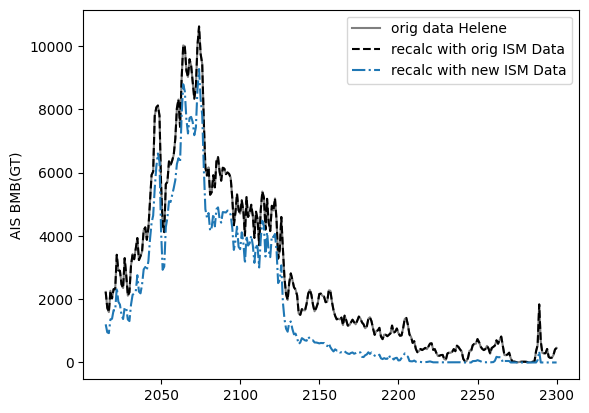

In [95]:
fac = -1* 3600 *24*365.25 /10**12
f,ax = plt.subplots(1,1)
ax.plot(d_bmb_helene.time,d_bmb_helene[f'{variable}'].values*fac,label ='orig data Helene',color = 'black',alpha = 0.5)
ax.plot(d_bmb_helene.time,shelfmelt_total*fac,linestyle = '--',label ='recalc with orig ISM Data',color = 'black',)
ax.plot(d_bmb_helene.time,shelfmelt_total_new*fac,linestyle = '-.',label =f'recalc with new ISM Data')
ax.legend()
ax.set_ylabel('AIS BMB(GT)')
f.savefig('figs/IMAU_example_newBMB_AIS.pdf')

## recalc flaoting shelf

In [93]:
## recalc using old flatoing mask
shelf_total=np.sum(d_maskfloat['sftflf'].values *d_icemask['sftgif'].values*scalefac_model.af2.values,axis=(1,2))*(eval(res)*1000.0)**2 #in kg/s
shelf_total_new=np.sum(d_maskfloat_new['sftflf'].values *d_icemask['sftgif'].values*scalefac_model.af2.values,axis=(1,2))*(eval(res)*1000.0)**2 #in kg/s

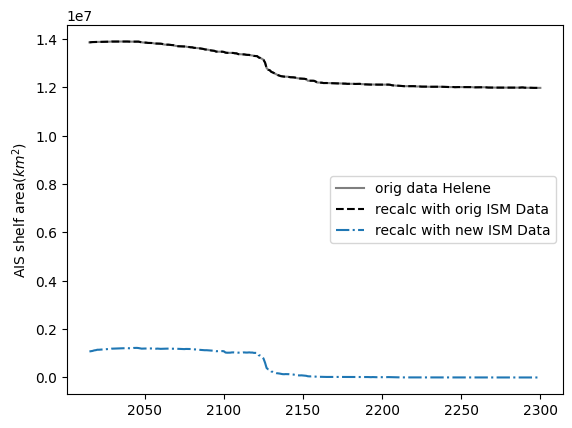

In [94]:
fac = 1/1000**2
f,ax = plt.subplots(1,1)
ax.plot(d_bmb_helene.time,d_shelfarea_helene[f'{variable2}'].values*fac,label ='orig data Helene',color = 'black',alpha = 0.5)
ax.plot(d_bmb_helene.time,shelf_total*fac,linestyle = '--',label ='recalc with orig ISM Data',color = 'black',)
ax.plot(d_bmb_helene.time,shelf_total_new*fac,linestyle = '-.',label =f'recalc with new ISM Data')
ax.legend()
ax.set_ylabel('AIS shelf area($km^2$)')
f.savefig('figs/IMAU_example_newshelfarea_AIS.pdf')